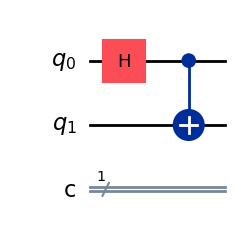

In [1]:
## DO A HELLO WORLD PROGRAM USING QISKIT(BRING 2 QUBITS TO A BELL STATE)

## STEP 1: MAP THE PROBLEM TO CIRCUITS AND OPERATORS

from qiskit import QuantumCircuit

qc = QuantumCircuit(2,1)

qc.h(0)
qc.cx(0,1)


qc.draw(output="mpl")



In [ ]:
## Step 2: Optimize

In [4]:
## Step 3 : Execute in backend


from qiskit.quantum_info import Pauli
ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")
XX = Pauli("XX")
XI = Pauli("XI")
IX = Pauli("IX")

observables = [ZZ,ZI,IZ,XX,XI,IX]


from qiskit_aer.primitives import Estimator


estimator = Estimator()

job =  estimator.run([qc]*len(observables),observables=observables)

job.result()

EstimatorResult(values=array([ 1.        , -0.015625  , -0.015625  ,  1.        , -0.01367188,
       -0.01367188]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0023144, 'sample_measure_time': 0.0007995, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 16163, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 8, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.999755859375, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0023144, 'sample_measure_time': 0.0007995, 

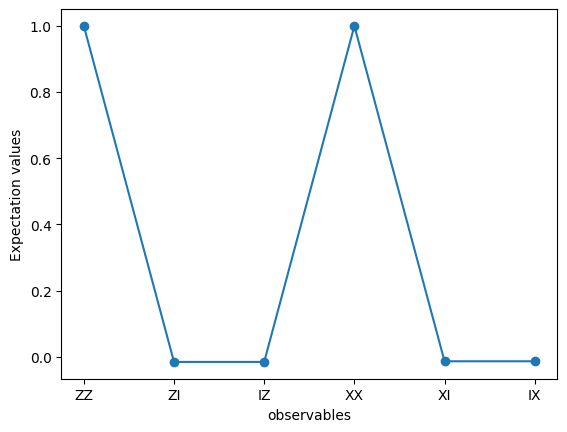

In [5]:
## Step 4: Post processing and plotting

import matplotlib.pyplot as plt

data = ["ZZ","ZI","IZ","XX","XI","IX"]

values = job.result().values

plt.plot(data,values,"-o")

plt.xlabel("observables")

plt.ylabel("Expectation values")

plt.show()

In [4]:
import random
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import Aer, AerSimulator
from qiskit import transpile


n_qubits = 10

# Step 1 - Alice choses randomly the bits and the bases
alice_bits = [random.randint(0,1) for _ in range(n_qubits)]
alice_bases = [random.choice(['Z', 'X']) for _ in range(n_qubits)]


#Step 2 - Bob Choses randomly measurement basis
bob_bases = [random.choice(['Z', 'X']) for _ in range(n_qubits)]

bob_results = []

# We will use a simulator to run the circuit
backend = Aer.get_backend("aer_simulator")

#For each qbit create a quantum circuit to simulate state preparation and measurements
for i in range(n_qubits):

  qc = QuantumCircuit(1,1) #one quantum bit and one classical bit
  # ----------- Alice state circuit preparation
  if alice_bases[i] == 'Z':
    ## In the Z basis, bit 0 is |0> and bit 1 is |1>
    ## If the bit is 1 flip it
    if alice_bits[i] == 1:
      qc.x(0)
  else:
    ## For the X basis, prepare |+> for bit 0 and |-> for bit 1.
    if alice_bits[i] == 0:
      qc.h(0)
    else:
      qc.x(0)
      qc.h(0)

## State Preparation Details:
## - When using the Z basis (computational basis), a bit 0 is encoded as |0⟩ and a bit 1 as |1⟩ (by applying an X gate).
## - When using the X basis (diagonal basis), a bit 0 is encoded as |+⟩ and a bit 1 as |−⟩.
##
## The Hadamard gate (H) is used to transform computational basis states into diagonal basis states:
##   H|0⟩ = |+⟩  and  H|1⟩ = |−⟩.
##
## This transformation is crucial in quantum key distribution protocols (e.g., BB84). If a qubit prepared in one basis
## is measured in a different basis, the measurement outcome becomes random (with a 50-50 probability), which is a key
## property that ensures the security of the protocol.

  ## Bob's measurements

  # if Bob's base is X apply Hadamard to prepare for measurements
  # Notice that there is a 50 - 50 chance of the qbit collapsing as 0 or 1
  if bob_bases[i] == 'X':
    qc.h(0)

  qc.measure(0,0)

  new_cirq = transpile(qc, backend)
  job = backend.run(new_cirq)

  counts = job.result().get_counts()

  measured_bit = int(list(counts.keys())[0])
  bob_results.append(measured_bit)

  # Alice and Bob reveal their bases over a public channel and only keep the bits where their bases match
sifted_key = []
for i in range(n_qubits):
  if alice_bases[i] == bob_bases[i]:
    sifted_key.append(alice_bits[i])
    print(f"Qubit {i}: Basis match ({alice_bases[i]}). Alice's bit: {alice_bits[i]}, Bob's measurement: {bob_results[i]}")
  else:
    print(f"Qubit {i}: Basis mismatch ({alice_bases[i]}). Alice's bit: {alice_bits[i]}, Bob's measurement: {bob_results[i]}")
  
print("\nFinal sifted key:", sifted_key)

Qubit 0: Basis match (X). Alice's bit: 1, Bob's measurement: 1
Qubit 1: Basis mismatch (X). Alice's bit: 0, Bob's measurement: 1
Qubit 2: Basis match (X). Alice's bit: 0, Bob's measurement: 0
Qubit 3: Basis mismatch (Z). Alice's bit: 0, Bob's measurement: 1
Qubit 4: Basis match (Z). Alice's bit: 0, Bob's measurement: 0
Qubit 5: Basis mismatch (Z). Alice's bit: 0, Bob's measurement: 0
Qubit 6: Basis match (X). Alice's bit: 0, Bob's measurement: 0
Qubit 7: Basis mismatch (Z). Alice's bit: 0, Bob's measurement: 0
Qubit 8: Basis mismatch (Z). Alice's bit: 0, Bob's measurement: 1
Qubit 9: Basis mismatch (Z). Alice's bit: 0, Bob's measurement: 0

Final sifted key: [1, 0, 0, 0]
